# Stage 5B — Controlled orientation normalization

Post-confirmation PCB2 development experiment. This notebook reads saved small
publication artifacts and figures. It never loads raw images, weights, reference
banks or cache maps, and never performs inference, fitting or threshold tuning.
The exact historical Stage 4 D1 bank and thresholds remain the matched baseline.
Only confidently reversed crops receive exact 180° rotation; uncertain cases
remain unchanged. All maps are returned to original source coordinates before
comparison with the untouched union GT masks.

In [1]:
from pathlib import Path
import json, hashlib, io
import pandas as pd
from PIL import Image as PILImage
from IPython.display import display, Image, Markdown
root=Path.cwd()
if not (root/'artifacts').is_dir(): root=root.parent
base=root/'artifacts/stage5b'
def table(name): return pd.read_csv(base/name)
def show(name):
    with PILImage.open(base/'figures'/name) as im:
        im.thumbnail((1100,1800)); buf=io.BytesIO(); im.save(buf,format='PNG')
    display(Image(data=buf.getvalue()))
review=json.loads((base/'independent_review.json').read_text())
assert review['passed']
metrics=json.loads((base/'results/modified_d1_metrics.json').read_text())
display(pd.json_normalize(metrics).T)
print('Independent saved-output review passed.')

,0
scope,post-confirmation PCB2 development evidence
total_fp_pixels,381516
historical_baseline.role,primary
historical_baseline.input_size,256
historical_baseline.image.n_images,200
...,...
missing.historical_detected,12
missing.normalized_detected,11
small_R1_R2.count,29
small_R1_R2.historical_detected,15


Independent saved-output review passed.


## All five reversed cases

The primary target was fixed before inference. Report every reversed case, not a
selection of favorable examples. Common-256 FP counts, pixel AP and IoU differ
from native unpadded-content spread. Scores divided by the frozen pixel threshold
are anomaly response ratios, not probabilities.

,image_id,source_labels,mask_area,historical_detected,normalized_detected,historical_image_score,normalized_image_score,historical_pixel_ap,normalized_pixel_ap,historical_fp_pixels,...,historical_iou,normalized_iou,historical_map_spread,normalized_map_spread,historical_gt_max_score,normalized_gt_max_score,historical_outside_gt_max_score,normalized_outside_gt_max_score,absolute_delta,relative_delta
0,735d89d870bbb25b3bc3dfce,"[""melt""]",168,True,True,2.861748,1.650754,0.004845,0.214432,29697,...,0.005625,0.058656,0.989474,0.743359,1.993668,1.583135,2.807536,1.617654,-27052,-0.910934
1,9bd08200d5d939f4a498aae7,"[""missing""]",1104,True,True,2.865720,2.619817,0.075694,0.834961,28440,...,0.037368,0.302632,1.000000,0.727280,2.476063,2.594995,2.830130,2.494903,-25896,-0.910549
2,2bea857039ef9c03907fb299,"[""missing""]",1152,True,True,2.928387,2.529640,0.491829,0.848447,31238,...,0.035567,0.163892,0.979275,0.932238,2.907056,2.512183,2.859809,2.453922,-25361,-0.811864
3,76964f3ab9f7c03b08de6900,"[""missing""]",2012,True,True,2.827421,2.804057,0.412118,0.831389,28422,...,0.066110,0.251752,0.989529,0.662876,2.809210,2.767884,2.753811,2.633959,-22442,-0.789600
4,bfebbd19caf4dad38fd66eab,"[""missing""]",50,True,False,2.725965,1.580128,0.001708,0.025757,29180,...,0.001711,0.026701,0.951613,0.803721,2.069566,1.446418,2.685587,1.545463,-28069,-0.961926


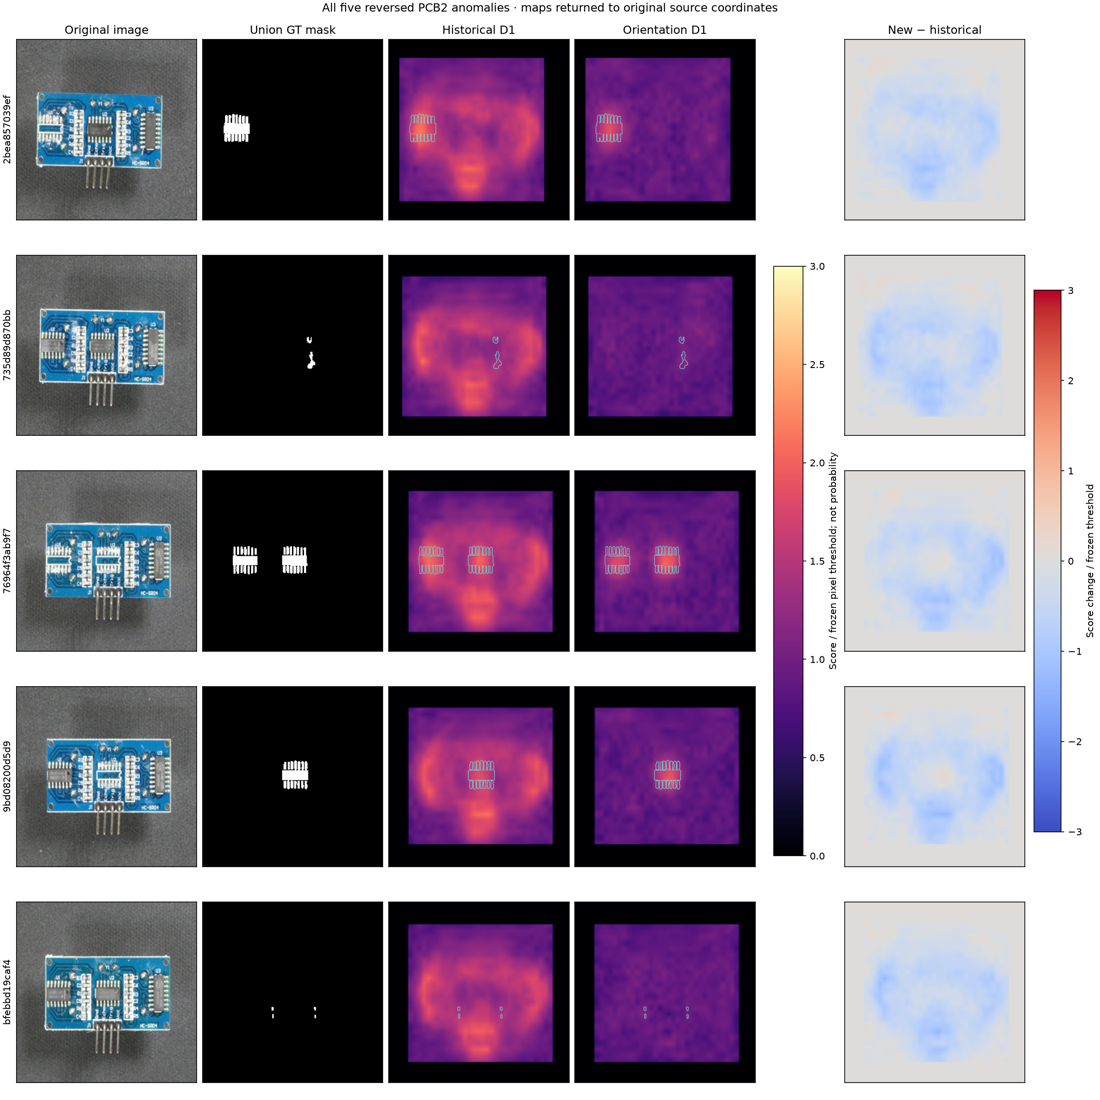

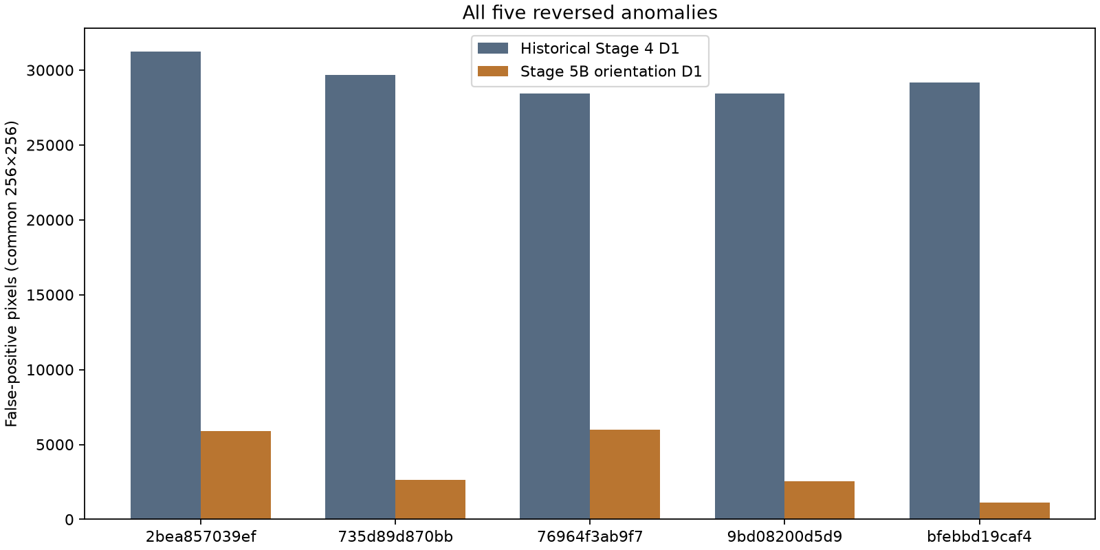

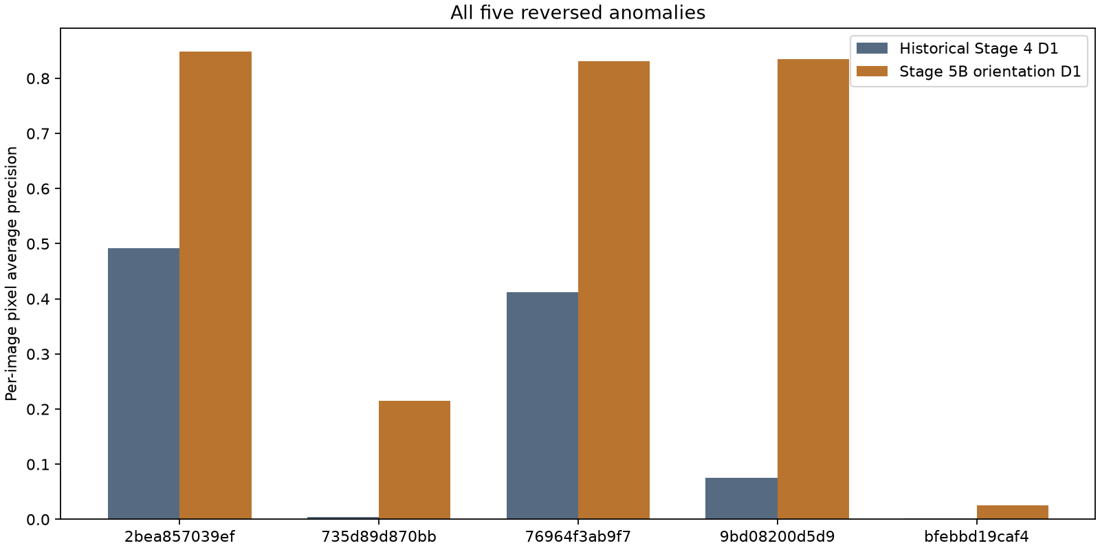

In [2]:
paired=table('results/reversed_paired_results.csv')
assert len(paired)==5 and paired.image_id.is_unique
display(paired)
show('reversed_before_after.png')
show('reversed_fp_pixels.png')
show('reversed_pixel_ap.png')

## Transform and defect signal

Rotation precedes historical letterboxing. Unpadded map content is resized back to
crop dimensions, inverse-rotated, pasted at the original crop location and finally
resized to common 256. The original source and annotation remain unchanged.
Disappeared and newly added exceedances distinguish suppression of background
response from loss of defect evidence.

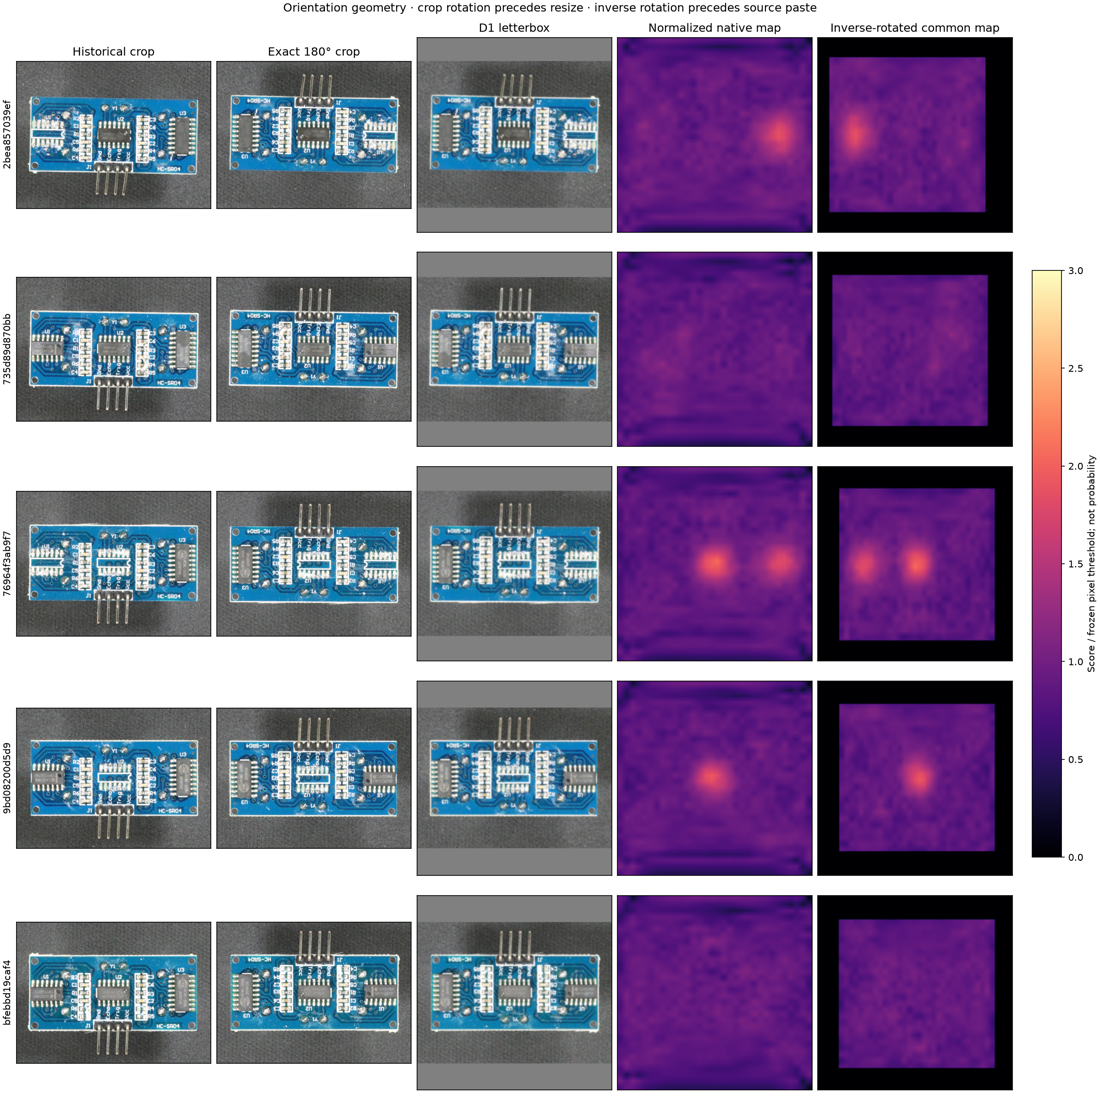

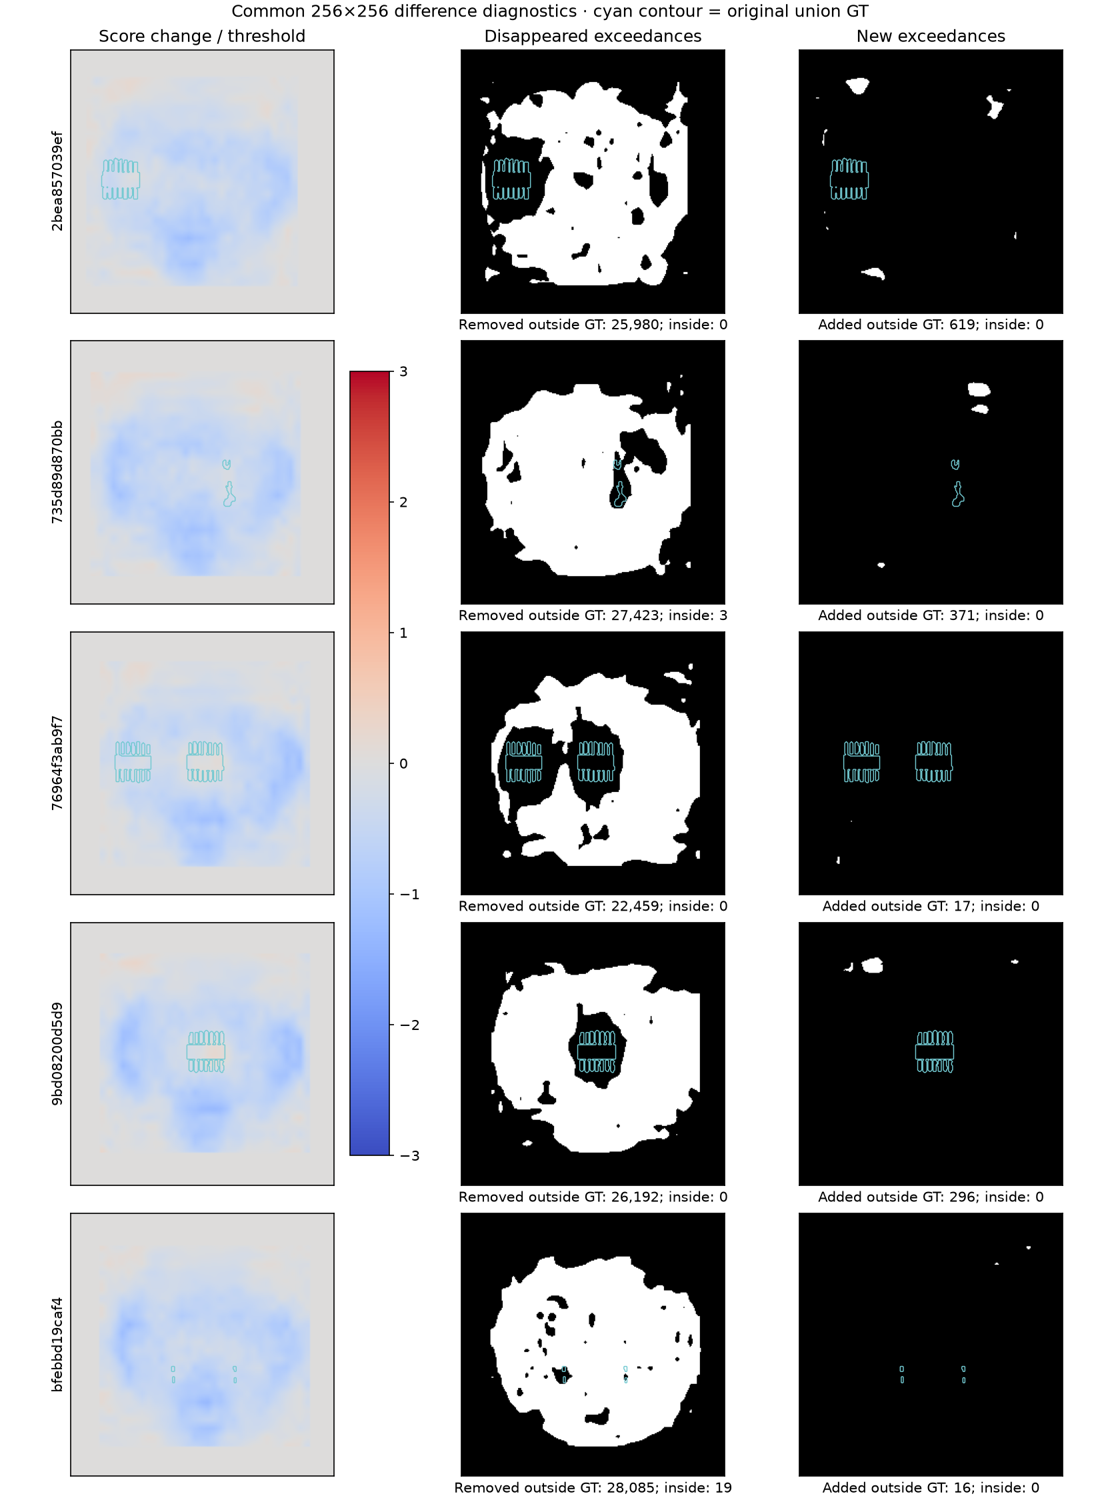

,image_id,mean_delta,min_delta,max_delta,mean_absolute_delta,removed_exceedances,removed_outside_gt,removed_inside_gt,new_exceedances,new_outside_gt,new_inside_gt
0,735d89d870bbb25b3bc3dfce,-0.321307,-1.503086,0.329196,0.331423,27426,27423,3,371,371,0
1,9bd08200d5d939f4a498aae7,-0.311474,-1.737884,0.386988,0.319735,26192,26192,0,296,296,0
2,2bea857039ef9c03907fb299,-0.286211,-1.631592,0.266021,0.294597,25980,25980,0,619,619,0
3,76964f3ab9f7c03b08de6900,-0.293401,-1.596049,0.252541,0.298639,22459,22459,0,17,17,0
4,bfebbd19caf4dad38fd66eab,-0.319916,-1.737784,0.245370,0.324923,28104,28085,19,16,16,0


,image_id,view,grid_row,grid_column,historical_denominator_pixels,normalized_denominator_pixels,historical_gt_positive_pixels,normalized_gt_positive_pixels,historical_predicted_positive_pixels,normalized_predicted_positive_pixels,...,historical_union_pixels,normalized_union_pixels,historical_false_positive_pixels,normalized_false_positive_pixels,historical_mean_raw_score,normalized_mean_raw_score,historical_threshold_exceedance_fraction,normalized_threshold_exceedance_fraction,historical_score_sum,normalized_score_sum
0,735d89d870bbb25b3bc3dfce,common256_crop,0,0,2550,2550,0,0,443,0,...,443,0,443,0,1.197366,1.165636,0.173725,0.000000,3053.282020,2972.371943
1,735d89d870bbb25b3bc3dfce,common256_crop,0,1,2550,2550,0,0,1597,0,...,1597,0,1597,0,1.414232,1.122999,0.626275,0.000000,3606.292282,2863.647285
2,735d89d870bbb25b3bc3dfce,common256_crop,0,2,2600,2600,0,0,1532,169,...,1532,169,1532,169,1.387602,1.160902,0.589231,0.065000,3607.765324,3018.343900
3,735d89d870bbb25b3bc3dfce,common256_crop,0,3,2550,2550,0,0,417,248,...,417,248,417,248,1.243222,1.171218,0.163529,0.097255,3170.215324,2986.606705
4,735d89d870bbb25b3bc3dfce,common256_crop,1,0,2550,2550,0,0,2286,251,...,2286,251,2286,251,1.961632,1.223838,0.896471,0.098431,5002.161030,3120.787911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,bfebbd19caf4dad38fd66eab,native_content,2,3,2944,2944,0,0,2734,36,...,2734,36,2734,36,1.929220,1.196615,0.928668,0.012228,5679.623866,3522.835879
156,bfebbd19caf4dad38fd66eab,native_content,3,0,3008,3008,0,0,535,2,...,535,2,535,2,1.239701,1.117290,0.177859,0.000665,3729.021627,3360.809315
157,bfebbd19caf4dad38fd66eab,native_content,3,1,3008,3008,0,0,2717,99,...,2717,99,2717,99,1.928902,1.164582,0.903258,0.032912,5802.135350,3503.063819
158,bfebbd19caf4dad38fd66eab,native_content,3,2,3008,3008,0,0,2867,204,...,2867,204,2867,204,1.923196,1.174698,0.953125,0.067819,5784.972473,3533.492714


In [3]:
show('orientation_geometry.png')
show('reversed_map_differences.png')
display(table('results/map_difference_statistics.csv'))
display(table('regional/reversed_grid_comparison.csv'))

## No-op controls and engineering cost

All 195 canonical/uncertain evaluation images were independently rerun through the
new wrapper. Saved comparisons test actual equality, rather than copying baseline
outputs. No reversed normal group exists: unchanged normal flags test implementation
integrity, not reversed-normal robustness. Runtime is measured separately from
scientific benefit.

In [4]:
controls=table('results/no_op_invariance.csv')
assert len(controls)==195 and controls.image_id.is_unique
display(controls)
display(table('results/runtime.csv').describe(include='all').T)
display(Markdown((base/'findings.md').read_text()))

,image_id,label,pose_label,action_no_op,tensor_exact,score_exact,flag_exact,model_map_exact,common_map_exact,pixel_ap_exact,fp_pixels_exact,passed
0,fea34ce33cdd25b0ede4efe4,anomaly,canonical,True,True,True,True,True,True,True,True,True
1,596996fa0816db1d904389d5,anomaly,canonical,True,True,True,True,True,True,True,True,True
2,0333ff525de4a8a11f200628,anomaly,canonical,True,True,True,True,True,True,True,True,True
3,40bd4bb7b874a3ca7af54e0d,anomaly,canonical,True,True,True,True,True,True,True,True,True
4,14a83651ed9a4f616caa6729,anomaly,canonical,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
190,096528d5d7875e34d1ce7795,normal,canonical,True,True,True,True,True,True,True,True,True
191,b2c29250de881ef717620575,normal,canonical,True,True,True,True,True,True,True,True,True
192,2f3b3f7aaf40cd0b5e920590,normal,canonical,True,True,True,True,True,True,True,True,True
193,926f45ae46975296f27d7760,normal,canonical,True,True,True,True,True,True,True,True,True


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
image_id,200,200,fea34ce33cdd25b0ede4efe4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pose_label,200,3,canonical,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geometry_seconds,200.0,NaN,NaN,NaN,0.01465,0.000597,0.014126,0.014331,0.014448,0.014706,0.018384
pose_seconds,200.0,NaN,NaN,NaN,0.046076,0.002075,0.044007,0.044917,0.045444,0.046485,0.065666
rotation_seconds,200.0,NaN,NaN,NaN,0.0001,0.000624,0.0,0.0,0.0,0.0,0.004146
total_preprocessing_seconds,200.0,NaN,NaN,NaN,0.063955,0.002884,0.061273,0.06219,0.062955,0.064612,0.089838
d1_inference_seconds,200.0,NaN,NaN,NaN,0.293991,0.018822,0.279307,0.28428,0.287656,0.295391,0.431915
inverse_map_seconds,200.0,NaN,NaN,NaN,0.005315,0.000805,0.004824,0.004997,0.005145,0.00533,0.014583
end_to_end_seconds,200.0,NaN,NaN,NaN,0.37024,0.021346,0.351099,0.358828,0.363606,0.371841,0.515338


# Stage 5B — Orientation tightens reversed maps but loses one detection

Completed and independently audited October 4, 2026 (America/Vancouver). **Post-confirmation PCB2 development evidence.** Historical Stage 4 D1 remains the primary result. Orientation normalization is **not adopted unconditionally**: the unchanged image threshold detects only four of the five previously detected reversed anomalies.

## Why this experiment

The supplied handoff was reviewed against Stage 5A in [the plan review](../../docs/development/stage5b_plan_review.md). Five reversed anomalies generated 146,977 common-256 false-positive pixels, 28.80% of D1's 510,336 total. All five were detected already. Canonical missing-label misses retrieve local normal references, so this experiment tests pose mismatch as a contributor to broad maps; it does not test spatially restricted matching.

## Frozen intervention and controls

Reuse the exact Stage 4 D1 4,096×384 bank, ResNet18 layer2/layer3 features and local aggregation, 256 input, Euclidean distance, maximum-patch image score, crop, letterbox and interpolation. No fitting, augmentation, recalibration or tuning occurred. Image threshold is **1.6270664930343628**, pixel threshold **1.348502516746521**, strict `>`.

The unchanged Stage 5A pin classifier receives full original source RGB and original board box. Canonical and uncertain crops are unchanged; only the five `reversed_180` crops receive exact vertical/horizontal array reversal before resizing and letterboxing. The map is unpadded, bilinearly resized to crop dimensions, inverse-reversed, pasted at the original crop location and finally resized to common 256. Original GT masks remain untouched. Odd-padding/asymmetric-crop tests guard this order. See [protocol](orientation_protocol.json), [freeze](freeze_receipt.json) and [geometry figure](figures/orientation_geometry.png).

The freeze uses Stage 4 commit `2ec21c4686c7dad7d60c177cb35fed2cd62d9280` and the actual uncommitted Stage 5A receipt identity rather than inventing a Stage 5A commit. Every one of the 1,101 original pose labels reproduced. All 195 non-reversed evaluation images were rerun through D1: tensors, scores, flags, native/common arrays, applicable AP and FP counts match **exactly**, with no numerical tolerance. The 100 normal flags remain 5/100. These are implementation controls, not a reversed-normal robustness test.

## All five paired cases

Common-256 maps cover the original source image. Pixel AP/FP/intersection counts below use that space; native crop spread excludes padding and has a different denominator.

| Image ID | Source label | FP pixels: historical → normalized | Pixel AP: historical → normalized | Image score: historical → normalized | Detection | GT intersection: historical → normalized |
| --- | --- | ---: | ---: | ---: | --- | ---: |
| `2bea857039ef9c03907fb299` | missing | 31,238 → 5,877 | 0.4918 → 0.8484 | 2.928387 → 2.529640 | Retained | 1152 → 1152 |
| `735d89d870bbb25b3bc3dfce` | melt | 29,697 → 2,645 | 0.0048 → 0.2144 | 2.861748 → 1.650754 | Retained | 168 → 165 |
| `76964f3ab9f7c03b08de6900` | missing | 28,422 → 5,980 | 0.4121 → 0.8314 | 2.827421 → 2.804057 | Retained | 2012 → 2012 |
| `9bd08200d5d939f4a498aae7` | missing | 28,440 → 2,544 | 0.0757 → 0.8350 | 2.865720 → 2.619817 | Retained | 1104 → 1104 |
| `bfebbd19caf4dad38fd66eab` | missing | 29,180 → 1,111 | 0.0017 → 0.0258 | 2.725965 → 1.580128 | Lost | 50 → 31 |

All five FP counts decline and all five pixel APs improve. Total reversed FP pixels fall **146,977 → 18,157 (87.65%)**; median **29,180 → 2,645**. Median reversed AP rises **0.0757 → 0.8314**. Median native crop fraction above the frozen pixel threshold falls **0.7465 → 0.0927**. The positive bounding-box fraction and eight-connected component counts remain available separately in [per-image results](results/per_image_results.csv); a crop-wide bounding box can persist even when exceedances become sparse.

The detection guardrail fails: **5/5 → 4/5**. Missing-labeled image `bfebbd19caf4dad38fd66eab` falls from image score **2.725965 → 1.580128**, below the unchanged 1.627066 threshold. Its GT intersection declines **50 → 31** common pixels while outside-GT FP falls **29,180 → 1,111**. Its AP improves only **0.0017 → 0.0258**, remaining poor. Removing broad mismatch has not preserved enough image-level anomaly signal in this case. The melt case retains detection narrowly at **1.650754**; no statistical robustness margin is inferred.

![All five paired source-space maps](figures/reversed_before_after.png)

![Removed and new threshold exceedances](figures/reversed_map_differences.png)

All five cases are shown on a shared clipped score/pixel-threshold scale (0–3), not probability. Signed differences use −3–3. The [difference statistics](results/map_difference_statistics.csv) separate removed response inside versus outside GT and newly added exceedances. The [fixed 4×4 grid](regional/reversed_grid_comparison.csv) preserves both native-content and common-256 original-crop coordinate views; crop cells are not anatomical segmentation. The paired FP totals reconcile with common-256 grids.

## Full 200-image impact

| Quantity | Historical Stage 4 D1 | Stage 5B orientation D1 |
| --- | ---: | ---: |
| TP / FN | 80 / 20 | 79 / 21 |
| FP / TN | 5 / 95 | 5 / 95 |
| Image AP | 0.9604 | 0.9587 |
| AUROC | 0.9499 | 0.9484 |
| Median anomaly pixel AP | 0.3245 | 0.3329 |
| Pooled pixel AP, including normals | 0.1534 | 0.3142 |
| Pixel IoU, including normals | 0.04744 | 0.06234 |
| Peak inside /100 | 44 | 45 |
| Any overlap /100 | 97 | 97 |
| All-image FP pixels | 510,336 | 381,516 |
| Missing-label detection /19 | 12 | 11 |
| Fixed small R1/R2 detection /29 | 15 | 14 |

All seven historical canonical missing-label misses remain unchanged. The new miss is one of four reversed missing-labeled examples; total missing recall was not assumed invariant. Small-defect detection loses the same image, rather than improving through resolution. Canonical map weaknesses remain untouched by this experiment. Pooled AP improves alongside a much larger reduction in thresholded outside-GT burden, despite a slight intersection decline. AP measures ranking and does not follow directly from thresholded FP counts; this does not imply every defect is better detected.

## Engineering cost and timing limits

Measured median end-to-end inference is **0.3636 s**, p95 **0.4049 s**. Reversed median is **0.3664 s**, no-op median **0.3634 s**. Pose classification median is **45.44 ms**; actual crop-array rotation median over five reversed cases is **3.958 ms**. Process peak RSS is **1.417 GiB**, below the inherited 8 GiB cap.

The per-image timer includes source decoding, geometry, pose and tensor construction, frozen `score_feature` (which includes its historical common inverse), and additional source/common orientation inverses. It excludes GT metrics, artifact saving, the no-op tensor check, model loading and the separate 1,101-image label audit; first image is retained. Timers are nested and must not be added. The runtime figure summarizes all 200 images, so its rotation median/p95 are zero because only five images rotate; the 3.958 ms rotation median above uses the five reversed cases only. Retaining frozen scoring introduces redundant inverse work in this research implementation; it is disclosed rather than attributed entirely to pose overhead. Historical **0.2918 s** includes preprocessing and historical inverse mapping, so it is contextual, not a matched isolated-model comparison. [Per-image timers](results/runtime.csv) preserve boundaries and [runtime figure](figures/runtime.png) shows median/p95.

## Interpretation and decision

**Mixed support.** Exact controls and the across-case reduction support orientation mismatch as an actionable contributor to broad responses on these five observed reversed boards. The paired localization benefit is large, but the predeclared 5/5 detection guardrail fails. Keep the historical D1 pipeline as the primary; retain this orientation implementation as an experimental candidate, not an unconditional replacement. Do not lower thresholds, augment the bank, modify uncertain handling or tune this completed experiment.

A separate next study should ask: **How can orientation normalization preserve true defect signal while reducing broad pose-induced response?** Investigate the newly missed small missing-component case and the narrow-margin melt case alongside unresolved canonical missing/small-defect mechanisms before selecting a Stage 5C intervention. A representation/resolution or operating-policy proposal needs its own evidence and freeze; spatial constraints remain unsupported as the automatic next step. No Stage 5C experiment or UI was started.

## Verification and preserved failure

The first attempt stopped on the first canonical image because blank normal AP cells made the historical CSV column a string. Tensor, score, flags, native/common maps and FP counts were already identical; converting AP to a number reproduced its exact float value. The repair is reader typing, not detector logic or tolerance. No reversed result had been examined. [Failed attempt notes](../stage5b_failed_v1/failure_notes.json), original frozen runner/tests and partial maps are preserved in separate failed namespaces. The final freeze followed the regression test.

The independent review audits original masks and raw saved maps, all200 inverse mappings, all195 controls, all1101 RGB labels, paired/grid/difference counts and full metrics. It also independently reconstructs the five reversed inputs and scores their frozen features using float64 SciPy distances; this is bounded independent re-extraction, not a second full-population run or model fitting. [The authoritative review](independent_review.json) passed: maximum independently reconstructed native-map error was 1.43×10⁻⁶ and image-score error 9.25×10⁻⁷ against float64 distances (predeclared 1e-5 limit). All 200 saved inverse maps and 195 no-op maps match exactly; the independent float64 tolerance applies only to the separately implemented numerical distance audit. All 130 tests pass. The [completion manifest](complete.json) binds final evidence, documentation, figures, tests and the executed notebook.

Only five reversed anomalies and no reversed normals exist. PCB2 is exposed development data; overlapping source labels, union GT masks and unknown physical-board identities limit causation and generalization. This result neither resolves all canonical failures nor establishes factory readiness. Stage 4 timing-clock and historical archive-transport caveats remain. Stage4 and Stage5A code, banks, thresholds and measured outputs are preserved; evolving navigation is saved before changes under `history_navigation/` so earlier receipt identities remain verifiable without rewriting historical receipts.


## Limits and reproducibility

Only five reversed anomalies were available, all from already exposed PCB2.
Overlapping labels, union masks and unknown physical-board identities limit
interpretation. Canonical missing/small defects remain separate questions. Stage 4
remains the historical primary and retains its original timing/transport caveats.
The freeze receipt, independent review and completion manifest bind the saved
code, inputs and outputs; large raw images and maps remain local.